# 📊Employee Attrition Analysis

## Introduction

Attrition refers to the rate at which employees leave an organization over a period of time.

Employee Attrition Rate is defined as the percentage of employees who leave the company compared to the average number of employees during a given time period.

This project aims to analyze employee data to identify key factors contributing to attrition and help organizations improve employee retention.
## Objectives

- Explore the dataset and its features  
- Analyze relationships between different variables  
- Identify key factors affecting employee attrition


## Import Libraries


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Load Dataset

In [4]:
df = pd.read_csv('HR_Analytics.csv')
df

,EmpID,Age,AgeGroup,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,RM297,18,18-25,Yes,Travel_Rarely,230,Research & Development,3,3,Life Sciences,...,3,80,0,0,2,3,0,0,0,0.0
1,RM302,18,18-25,No,Travel_Rarely,812,Sales,10,3,Medical,...,1,80,0,0,2,3,0,0,0,0.0
2,RM458,18,18-25,Yes,Travel_Frequently,1306,Sales,5,3,Marketing,...,4,80,0,0,3,3,0,0,0,0.0
3,RM728,18,18-25,No,Non-Travel,287,Research & Development,5,2,Life Sciences,...,4,80,0,0,2,3,0,0,0,0.0
4,RM829,18,18-25,Yes,Non-Travel,247,Research & Development,8,1,Medical,...,4,80,0,0,0,3,0,0,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1475,RM412,60,55+,No,Travel_Rarely,422,Research & Development,7,3,Life Sciences,...,4,80,0,33,5,1,29,8,11,10.0
1476,RM428,60,55+,No,Travel_Frequently,1499,Sales,28,3,Marketing,...,4,80,0,22,5,4,18,13,13,11.0
1477,RM537,60,55+,No,Travel_Rarely,1179,Sales,16,4,Marketing,...,4,80,0,10,1,3,2,2,2,2.0
1478,RM880,60,55+,No,Travel_Rarely,696,Sales,7,4,Marketing,...,2,80,1,12,3,3,11,7,1,9.0



## Data Cleaning


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1480 entries, 0 to 1479
Data columns (total 38 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   EmpID                     1480 non-null   object 
 1   Age                       1480 non-null   int64  
 2   AgeGroup                  1480 non-null   object 
 3   Attrition                 1480 non-null   object 
 4   BusinessTravel            1480 non-null   object 
 5   DailyRate                 1480 non-null   int64  
 6   Department                1480 non-null   object 
 7   DistanceFromHome          1480 non-null   int64  
 8   Education                 1480 non-null   int64  
 9   EducationField            1480 non-null   object 
 10  EmployeeCount             1480 non-null   int64  
 11  EmployeeNumber            1480 non-null   int64  
 12  EnvironmentSatisfaction   1480 non-null   int64  
 13  Gender                    1480 non-null   object 
 14  HourlyRa

### Handling Missing Values

In [6]:
df.isnull().sum()

EmpID                        0
Age                          0
AgeGroup                     0
Attrition                    0
BusinessTravel               0
DailyRate                    0
Department                   0
DistanceFromHome             0
Education                    0
EducationField               0
EmployeeCount                0
EmployeeNumber               0
EnvironmentSatisfaction      0
Gender                       0
HourlyRate                   0
JobInvolvement               0
JobLevel                     0
JobRole                      0
JobSatisfaction              0
MaritalStatus                0
MonthlyIncome                0
SalarySlab                   0
MonthlyRate                  0
NumCompaniesWorked           0
Over18                       0
OverTime                     0
PercentSalaryHike            0
PerformanceRating            0
RelationshipSatisfaction     0
StandardHours                0
StockOptionLevel             0
TotalWorkingYears            0
Training

In [7]:
df['YearsWithCurrManager'] = df['YearsWithCurrManager'].fillna(df['YearsWithCurrManager'].median())

Missing values in the 'YearsWithCurrManager' column were handled using the median value.

In [8]:
df.isnull().sum()

EmpID                       0
Age                         0
AgeGroup                    0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
SalarySlab                  0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBa

### Removing Duplicates

In [9]:
df[df.duplicated()]

,EmpID,Age,AgeGroup,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
211,RM1468,27,26-35,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,...,2,80,1,6,0,3,6,2,0,3.0
328,RM1461,29,26-35,No,Travel_Rarely,468,Research & Development,28,4,Medical,...,2,80,0,5,3,1,5,4,0,4.0
458,RM1464,31,26-35,No,Non-Travel,325,Research & Development,5,3,Medical,...,2,80,0,10,2,3,9,4,1,7.0
655,RM1470,34,26-35,No,TravelRarely,628,Research & Development,8,3,Medical,...,1,80,0,6,3,4,4,3,1,2.0
954,RM1463,39,36-45,No,Travel_Rarely,722,Sales,24,1,Marketing,...,1,80,1,21,2,2,20,9,9,6.0
1305,RM1469,49,46-55,No,Travel_Frequently,1023,Sales,2,3,Medical,...,4,80,0,17,3,2,9,6,0,8.0
1336,RM1462,50,46-55,Yes,Travel_Rarely,410,Sales,28,3,Marketing,...,2,80,1,20,3,3,3,2,2,0.0


In [10]:
df = df.drop_duplicates()

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df = df.drop(['EmpID', 'EmployeeNumber', 'EmployeeCount', 'StandardHours', 'Over18', 'AgeGroup', 'SalarySlab'], axis=1)

In [13]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,18,Yes,Travel_Rarely,230,Research & Development,3,3,Life Sciences,3,Male,...,3,3,0,0,2,3,0,0,0,0.0
1,18,No,Travel_Rarely,812,Sales,10,3,Medical,4,Female,...,3,1,0,0,2,3,0,0,0,0.0
2,18,Yes,Travel_Frequently,1306,Sales,5,3,Marketing,2,Male,...,3,4,0,0,3,3,0,0,0,0.0
3,18,No,Non-Travel,287,Research & Development,5,2,Life Sciences,2,Male,...,3,4,0,0,2,3,0,0,0,0.0
4,18,Yes,Non-Travel,247,Research & Development,8,1,Medical,3,Male,...,3,4,0,0,0,3,0,0,0,0.0


In [14]:
df.shape

(1473, 31)

In [15]:
df.tail()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
1475,60,No,Travel_Rarely,422,Research & Development,7,3,Life Sciences,1,Female,...,3,4,0,33,5,1,29,8,11,10.0
1476,60,No,Travel_Frequently,1499,Sales,28,3,Marketing,3,Female,...,3,4,0,22,5,4,18,13,13,11.0
1477,60,No,Travel_Rarely,1179,Sales,16,4,Marketing,1,Male,...,3,4,0,10,1,3,2,2,2,2.0
1478,60,No,Travel_Rarely,696,Sales,7,4,Marketing,2,Male,...,3,2,1,12,3,3,11,7,1,9.0
1479,60,No,Travel_Rarely,370,Research & Development,1,4,Medical,3,Male,...,4,3,1,19,2,4,1,0,0,0.0


## Exploratory Data Analysis (EDA)
### 1. Attrition Distribution

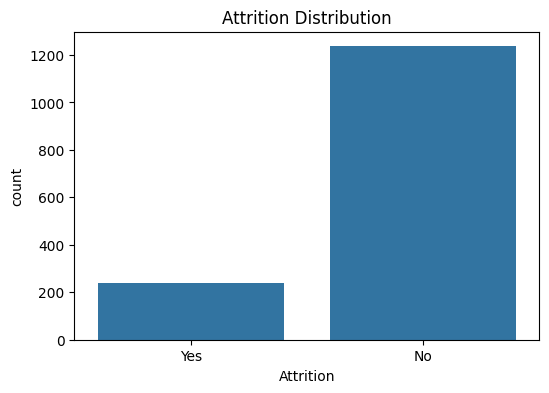

In [18]:
plt.figure(figsize=(6,4))
sns.countplot(x='Attrition', data=df)
plt.title("Attrition Distribution")
plt.show()

#### Insight
- Majority of employees have not left the company  
- A smaller portion of employees have attrited  
- Indicates moderate attrition that requires attention  

### 2. Age vs Attrition

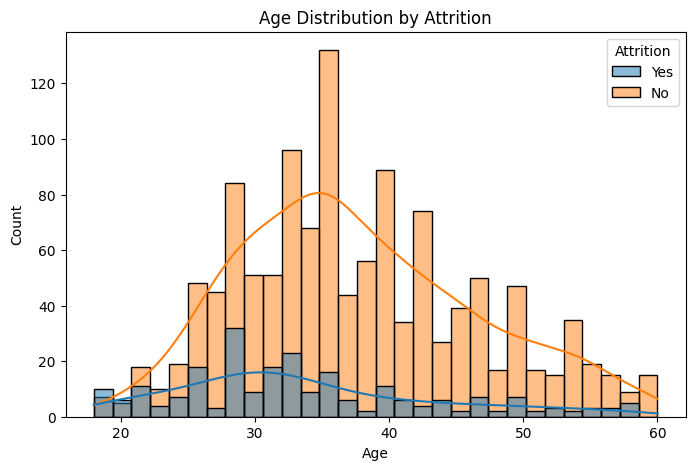

In [19]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='Age', hue='Attrition', bins=30, kde=True)
plt.title("Age Distribution by Attrition")
plt.show()

#### Insight
- Younger employees (especially 25–35) show relatively higher attrition compared to older groups
- However, majority of employees in all age groups still stay in the company
- Attrition decreases slightly with increasing age

### 3. Job Role vs Attrition

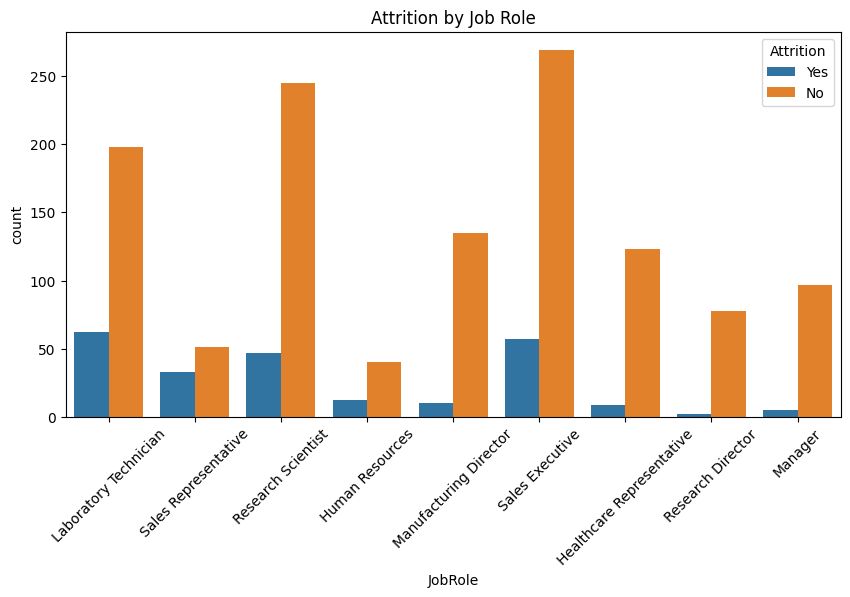

In [20]:
plt.figure(figsize=(10,5))
sns.countplot(x='JobRole', hue='Attrition', data=df)
plt.xticks(rotation=45)
plt.title("Attrition by Job Role")
plt.show()

#### Insight
- Sales Executive and Laboratory Technician roles show higher attrition counts
- Roles with high customer interaction or pressure may have higher turnover
- Some roles (like Manager/Research Director) show relatively lower attrition

### 4. Overtime vs Attrition

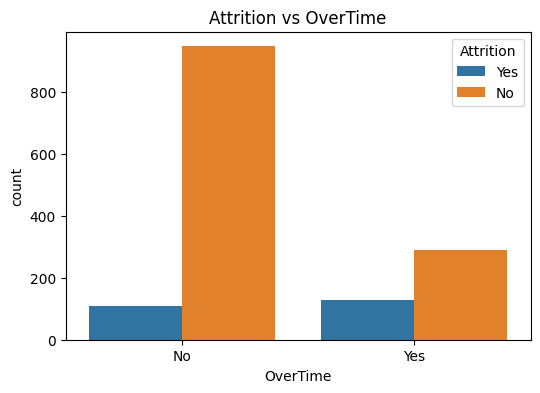

In [21]:
plt.figure(figsize=(6,4))
sns.countplot(x='OverTime', hue='Attrition', data=df)
plt.title("Attrition vs OverTime")
plt.show()

#### Insight
- Employees who work overtime show a significantly higher attrition rate
- Employees without overtime mostly stay in the company
- Suggests poor work-life balance is a strong factor in employee turnover

### 5. Monthly Income vs Attrition

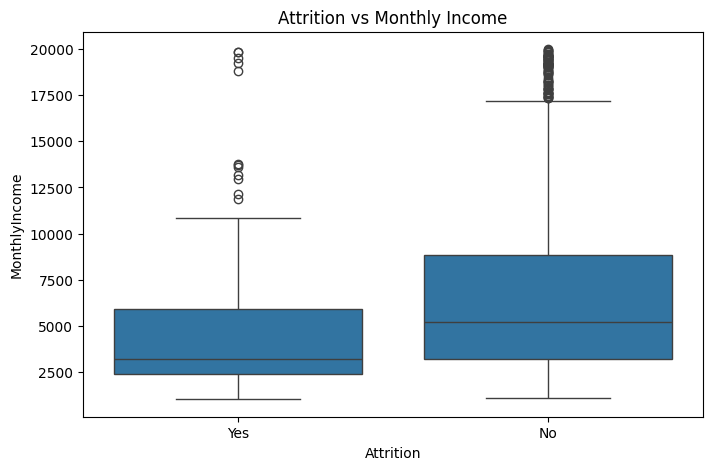

In [22]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Attrition', y='MonthlyIncome', data=df)
plt.title("Attrition vs Monthly Income")
plt.show()

#### Insight
- Lower income is associated with higher attrition  
- Salary is a key factor in retention  

### 6. Years at Company vs Attrition

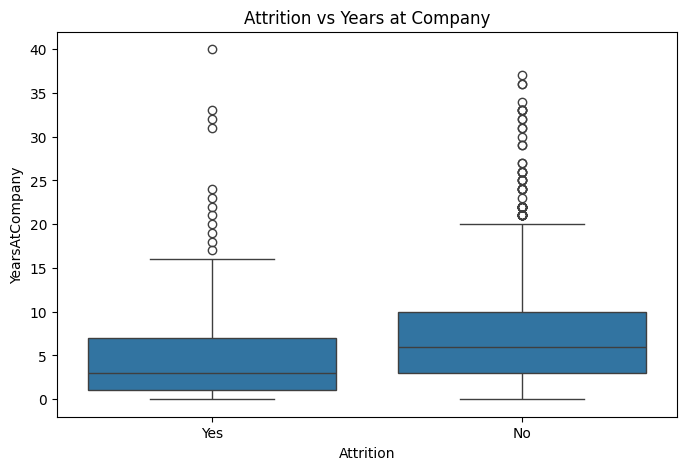

In [23]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Attrition', y='YearsAtCompany', data=df)
plt.title("Attrition vs Years at Company")
plt.show()

#### Insight
- Employees with fewer years at the company show higher attrition
- Employees who stay longer tend to have lower attrition
- This suggests attrition is highest during early stages of employment

### 7. Correlation Analysis

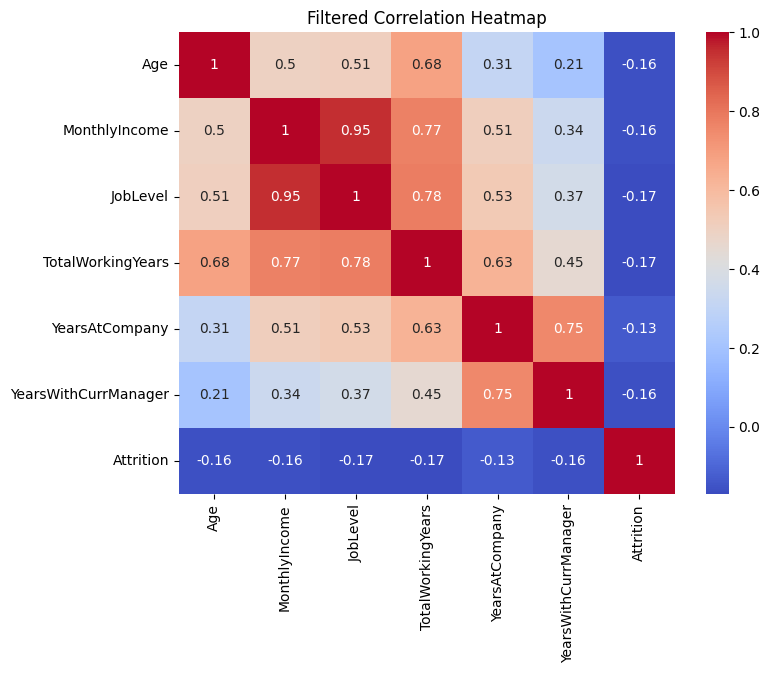

In [24]:
important_cols = [
    'Age',
    'MonthlyIncome',
    'JobLevel',
    'TotalWorkingYears',
    'YearsAtCompany',
    'YearsWithCurrManager',
    'Attrition'
]
df.loc[:, 'Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})

plt.figure(figsize=(8,6))
sns.heatmap(df[important_cols].corr(), annot=True, cmap='coolwarm')

plt.title("Filtered Correlation Heatmap")
plt.show()

#### Insight
- Monthly Income is negatively correlated with Attrition, indicating that employees with lower salaries are more likely to leave the company.  
- Experience (Total Working Years and Years at Company) shows a negative relationship with Attrition, meaning less experienced employees have a higher tendency to leave.  
- Job Level is positively correlated with Monthly Income, indicating that higher-level positions offer better salaries and are associated with lower attrition.

## Conclusion

- Employee attrition is relatively higher among younger employees and those in early career stages.  
- Employees with lower monthly income are more likely to leave the organization.  
- Work-life balance factors, such as overtime, have a significant impact on attrition.  
- Employees with less experience and fewer years at the company show a higher tendency to leave.  

### Recommendations

- Implement better work-life balance policies to reduce employee burnout.  
- Offer competitive salary packages to retain skilled employees.  
- Strengthen employee engagement and satisfaction initiatives.  
- Provide clear career growth opportunities and learning programs for early-career employees.  